# Hyperparameter Heatmap for Final Test Accuracy

This notebook creates a heatmap visualization showing how final test accuracy varies across different hyperparameter combinations in your experiments. The color intensity in the heatmap represents the median final test accuracy of defending nodes for each combination.

## 1. Import Required Libraries

In [1]:
import os
import sys
from pathlib import Path
import configparser
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import ipywidgets as widgets
from collections import defaultdict

## 2. Define Utility Functions

First, we'll define some utility functions to extract data from experiment result files and calculate metrics.

In [2]:
def extract_adversarial_nodes(config_path):
    """Extract adversarial nodes from config file"""
    if not os.path.exists(config_path):
        print(f"Warning: Config file not found at {config_path}")
        return []
        
    config = configparser.ConfigParser()
    config.read(config_path)
    
    try:
        if 'SHARING' in config and 'adversarial_nodes' in config['SHARING']:
            nodes_str = config['SHARING']['adversarial_nodes']
            return [int(node) for node in nodes_str.split(',')]
    except Exception as e:
        print(f"Error extracting adversarial nodes from config: {e}")
    
    return []


def extract_node_ids(filepaths):
    """Extract node IDs from CSV filenames"""
    node_ids = []
    for filepath in filepaths:
        # Filename format is "0_results.csv" where 0 is the node ID
        filename = os.path.basename(filepath)
        try:
            if '_results.csv' in filename:
                # Extract the part before "_results.csv"
                node_id = int(filename.split('_results.csv')[0])
                node_ids.append(node_id)
            else:
                node_ids.append(None)
        except (ValueError, IndexError):
            node_ids.append(None)
    
    return node_ids


def get_final_test_acc(results_path, adversarial_nodes=None):
    """Extract final test accuracy values for defending nodes"""
    folder_path = Path(results_path)
    if not folder_path.is_dir() or "weights" == folder_path.name:
        print(f"Warning: Invalid folder path: {results_path}")
        return []
    
    results = []
    filepaths = []
    
    # Check if this is a direct run folder or a parent folder with multiple run folders
    if any(Path(os.path.join(results_path, item)).is_dir() for item in os.listdir(results_path)):
        # This is a parent folder with multiple machine folders
        machine_folders = os.listdir(folder_path)
        for machine_folder in machine_folders:
            mf_path = os.path.join(folder_path, machine_folder)
            if not os.path.isdir(mf_path):
                continue
                
            files = [f for f in os.listdir(mf_path) if f.endswith("_results.csv")]
            
            for f in files:
                filepath = os.path.join(mf_path, f)
                try:
                    results.append(pd.read_csv(filepath, index_col=0))
                    filepaths.append(filepath)
                except Exception as e:
                    print(f"Error reading {filepath}: {e}")
    else:
        # This might be a direct CSV location
        files = [f for f in os.listdir(results_path) if f.endswith(".csv") and "_results" in f]
        for f in files:
            filepath = os.path.join(results_path, f)
            try:
                results.append(pd.read_csv(filepath, index_col=0))
                filepaths.append(filepath)
            except Exception as e:
                print(f"Error reading {filepath}: {e}")
    
    if not results:
        print(f"Warning: No result files found in {results_path}")
        return []
        
    # Extract node IDs from filenames
    node_ids = extract_node_ids(filepaths)
    
    # Collect final test accuracy values for defending nodes
    final_values = []
    for idx, result_df in enumerate(results):
        # Skip adversarial nodes
        if adversarial_nodes and node_ids[idx] in adversarial_nodes:
            continue
            
        # Skip if test_acc column doesn't exist
        if "test_acc" not in result_df.columns:
            continue
        
        # Get the last valid test accuracy value
        test_acc_series = result_df["test_acc"].dropna()
        if not test_acc_series.empty:
            final_value = test_acc_series.iloc[-1]  # Get the last value
            final_values.append(final_value)
    
    return final_values


def calculate_median_final_acc(final_values):
    """Calculate the median final test accuracy"""
    if not final_values:
        return np.nan
        
    return np.median(final_values)

## 3. Data Collection and Processing

Now we'll create a class to store and manage experiment run data. Each row will contain information about a single experiment run, including folder path, hyperparameter values, and final test accuracy.

In [3]:
class ExperimentDataCollector:
    def __init__(self):
        self.data = []
        self.columns = ['run_name', 'folder_path', 'median_final_acc', 'adversarial_nodes']
        self.hyperparam_names = set()
        
    def add_run(self, run_name, folder_path, hyperparam_dict=None, adversarial_nodes=None, config_path=None):
        """Add a new experiment run to the dataset"""
        # If config_path is provided and adversarial_nodes is not, extract from config
        if config_path and adversarial_nodes is None:
            adversarial_nodes = extract_adversarial_nodes(config_path)
            
        # If adversarial_nodes is a string, convert to list
        if isinstance(adversarial_nodes, str) and adversarial_nodes:
            adversarial_nodes = [int(node) for node in adversarial_nodes.split(',')]
        
        # Get final test accuracy values
        final_values = get_final_test_acc(folder_path, adversarial_nodes)
        median_acc = calculate_median_final_acc(final_values)
        
        # Create run data dictionary
        run_data = {
            'run_name': run_name,
            'folder_path': folder_path,
            'median_final_acc': median_acc,
            'adversarial_nodes': adversarial_nodes
        }
        
        # Add hyperparameter values
        if hyperparam_dict:
            for param_name, param_value in hyperparam_dict.items():
                run_data[param_name] = param_value
                self.hyperparam_names.add(param_name)
                if param_name not in self.columns:
                    self.columns.append(param_name)
        
        self.data.append(run_data)
        print(f"Added run '{run_name}' with median final accuracy: {median_acc:.2f}%")
        return run_data
    
    def get_dataframe(self):
        """Convert stored data to pandas DataFrame"""
        df = pd.DataFrame(self.data)
        # Ensure all columns are present (fill missing values with NaN)
        for col in self.columns:
            if col not in df.columns:
                df[col] = np.nan
        return df[self.columns]
    
    def get_hyperparameter_names(self):
        """Get the names of all hyperparameters in the dataset"""
        return sorted(list(self.hyperparam_names))
    
    def clear_data(self):
        """Clear all stored data"""
        self.data = []
        self.hyperparam_names = set()

Now let's create our experiment data collector instance:

In [23]:
# Initialize the experiment data collector
collector = ExperimentDataCollector()

## 4. Interactive Run Data Input

Now we'll create interactive widgets to input experiment run data:

In [5]:
def create_run_input_form():
    """Create a form for inputting experiment run data"""
    # Create form widgets
    run_name = widgets.Text(description='Run Name:', placeholder='e.g., Experiment1')
    folder_path = widgets.Text(description='Folder Path:', placeholder='e.g., /path/to/results')
    adv_nodes = widgets.Text(description='Adv Nodes:', placeholder='e.g., 0,1,2 or leave blank')
    config_path = widgets.Text(description='Config Path:', placeholder='e.g., /path/to/config.ini (optional)')
    
    # Hyperparameter input (dynamic)
    param_name = widgets.Text(description='Param Name:', placeholder='e.g., learning_rate')
    param_value = widgets.Text(description='Param Value:', placeholder='e.g., 0.01')
    
    # Store hyperparameters in a dictionary
    hyperparams = {}
    
    # Output for displaying messages
    output = widgets.Output()
    
    # Container for hyperparameter list
    hyperparam_list = widgets.VBox([])
    
    def add_hyperparam(_):
        """Add a hyperparameter to the list"""
        name = param_name.value.strip()
        value = param_value.value.strip()
        
        with output:
            if not name or not value:
                print("Both parameter name and value must be provided.")
                return
            
            # Try to convert value to a numeric type if possible
            try:
                # Try as int first
                numeric_value = int(value)
            except ValueError:
                try:
                    # Try as float if int fails
                    numeric_value = float(value)
                except ValueError:
                    # Keep as string if both fail
                    numeric_value = value
            
            hyperparams[name] = numeric_value
            print(f"Added hyperparameter: {name} = {numeric_value}")
            
            # Update the hyperparameter list display
            param_list = [widgets.HTML(f"<b>{k}:</b> {v}") for k, v in hyperparams.items()]
            hyperparam_list.children = param_list
            
            # Clear input fields for next parameter
            param_name.value = ''
            param_value.value = ''
    
    add_param_button = widgets.Button(description='Add Parameter')
    add_param_button.on_click(add_hyperparam)
    
    def clear_hyperparams(_):
        """Clear all hyperparameters"""
        with output:
            hyperparams.clear()
            hyperparam_list.children = []
            print("Cleared all hyperparameters.")
    
    clear_params_button = widgets.Button(description='Clear Parameters')
    clear_params_button.on_click(clear_hyperparams)
    
    def add_run(_):
        """Add the run to the experiment data collector"""
        with output:
            output.clear_output()
            if not run_name.value or not folder_path.value:
                print("Run name and folder path are required.")
                return
                
            try:
                adv_nodes_val = adv_nodes.value.strip() if adv_nodes.value.strip() else None
                config_path_val = config_path.value.strip() if config_path.value.strip() else None
                
                collector.add_run(
                    run_name=run_name.value.strip(),
                    folder_path=folder_path.value.strip(),
                    hyperparam_dict=hyperparams.copy(),
                    adversarial_nodes=adv_nodes_val,
                    config_path=config_path_val
                )
                
                # Clear form for next run
                run_name.value = ''
                folder_path.value = ''
                adv_nodes.value = ''
                config_path.value = ''
                hyperparams.clear()
                hyperparam_list.children = []
                
            except Exception as e:
                print(f"Error adding run: {e}")
    
    add_run_button = widgets.Button(description='Add Run', button_style='success')
    add_run_button.on_click(add_run)
    
    # Arrange the form layout
    form = widgets.VBox([
        widgets.HBox([run_name, folder_path]),
        widgets.HBox([adv_nodes, config_path]),
        widgets.HTML("<h4>Hyperparameters</h4>"),
        widgets.HBox([param_name, param_value]),
        widgets.HBox([add_param_button, clear_params_button]),
        widgets.HTML("<h4>Current Hyperparameters:</h4>"),
        hyperparam_list,
        add_run_button,
        output
    ])
    
    return form

Let's create and display the input form:

In [21]:
input_form = create_run_input_form()
display(input_form)

## 5. View and Manage Collected Data

In [6]:
def view_collected_data():
    """Display the collected experiment data"""
    df = collector.get_dataframe()
    if df.empty:
        print("No data collected yet.")
    else:
        display(df)
    return df

In [29]:
df = view_collected_data()

,run_name,folder_path,median_final_acc,adversarial_nodes,a,c
0,1c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.915,None,0,1
1,1c_1a,/home/pouponne/decentralized/shatter-poisoning...,72.850,[9],1,1
2,2c_0a,/home/pouponne/decentralized/shatter-poisoning...,74.200,None,0,2
3,2c_1a,/home/pouponne/decentralized/shatter-poisoning...,68.080,[9],1,2
4,3c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.915,None,0,3
...,...,...,...,...,...,...
61,4c_12a,/home/pouponne/decentralized/shatter-poisoning...,9.955,"[9, 16, 25, 3, 18, 23, 28, 1, 7, 12, 30, 13]",12,4
62,5c_10a,/home/pouponne/decentralized/shatter-poisoning...,62.010,"[9, 16, 25, 3, 18, 23, 28, 1, 7, 12]",10,5
63,5c_12a,/home/pouponne/decentralized/shatter-poisoning...,10.150,"[9, 16, 25, 3, 18, 23, 28, 1, 7, 12, 30, 13]",12,5
64,6c_10a,/home/pouponne/decentralized/shatter-poisoning...,61.730,"[9, 16, 25, 3, 18, 23, 28, 1, 7, 12]",10,6


You can clear all collected data if needed:

In [18]:
def clear_all_data():
    collector.clear_data()
    print("All collected data has been cleared.")

# Uncomment to clear all data
clear_all_data()

All collected data has been cleared.


## 6. Generate Heatmap Visualization

Now we'll create functions to generate the heatmap visualization:

The heatmap generation supports fixed minimum and maximum values for the color scale. This is useful for creating comparable heatmaps across different sets of experiments. By default, the color scale adapts to the range of values in each individual heatmap, but you can override this behavior by setting specific min/max values.

In [9]:
def create_heatmap(df, x_param, y_param, title=None, figsize=(10, 8), vmin=None, vmax=None):
    """Create a heatmap of median final test accuracy across hyperparameter combinations"""
    if df.empty:
        print("No data available for heatmap generation.")
        return
        
    if x_param not in df.columns or y_param not in df.columns:
        print(f"Parameters {x_param} and/or {y_param} not found in data.")
        return
    
    # Pivot the data to create a matrix for the heatmap
    try:
        pivot_df = df.pivot_table(
            index=y_param,         # Y-axis (rows)
            columns=x_param,       # X-axis (columns)
            values='median_final_acc',  # Values (color)
            aggfunc='median'       # Use median if multiple values exist
        )
    except Exception as e:
        print(f"Error creating pivot table: {e}")
        print("Ensure that your hyperparameter values can be used as heatmap indices (numeric or string).")
        return
    
    # Create figure and axes
    plt.figure(figsize=figsize)
    
    # Create the heatmap
    ax = sns.heatmap(
        pivot_df,
        annot=True,            # Show values in cells
        fmt=".2f",            # Format for annotations (2 decimal places)
        cmap="viridis",       # Color map (green-blue-purple)
        cbar_kws={'label': 'Median Final Test Accuracy (%)'},
        linewidths=0.5,
        linecolor='white',
        vmin=vmin,             # Minimum value for color scaling
        vmax=vmax              # Maximum value for color scaling
    )
    
    # Set title and labels
    if title:
        plt.title(title, fontsize=14, pad=20)
    else:
        plt.title(f'Median Final Test Accuracy Heatmap: {y_param} vs {x_param}', fontsize=14, pad=20)
        
    plt.xlabel(x_param, fontsize=12)
    plt.ylabel(y_param, fontsize=12)
    
    # Rotate x-axis labels for better readability if needed
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    return pivot_df

## 7. Interactive Parameter Selection for Heatmap

Now we'll create an interactive selector for the heatmap parameters:

In [10]:
def create_heatmap_selector():
    """Create a widget for selecting heatmap parameters"""
    # Get available hyperparameters
    hyperparam_options = collector.get_hyperparameter_names()
    if len(hyperparam_options) < 2:
        return widgets.HTML("<p style='color:red;'>Not enough hyperparameters collected. Add at least 2 different hyperparameters.</p>")
    
    # Create selectors for x and y axes parameters
    x_param = widgets.Dropdown(
        options=hyperparam_options,
        description='X-axis:',
        value=hyperparam_options[0] if hyperparam_options else None
    )
    
    y_param = widgets.Dropdown(
        options=hyperparam_options,
        description='Y-axis:',
        value=hyperparam_options[1] if len(hyperparam_options) > 1 else hyperparam_options[0] if hyperparam_options else None
    )
    
    title = widgets.Text(
        description='Title:',
        placeholder='Optional custom title'
    )
    
    # Add color scale controls
    use_fixed_colors = widgets.Checkbox(
        value=False,
        description='Fix color scale',
        tooltip='Check to use fixed min/max values for color scale'
    )
    
    vmin = widgets.FloatText(
        value=0.0,
        description='Min value:',
        disabled=True,
        tooltip='Minimum value for color scale'
    )
    
    vmax = widgets.FloatText(
        value=100.0,
        description='Max value:',
        disabled=True,
        tooltip='Maximum value for color scale'
    )
    
    # Enable/disable min/max inputs based on checkbox
    def toggle_color_scale(_):
        vmin.disabled = not use_fixed_colors.value
        vmax.disabled = not use_fixed_colors.value
    
    use_fixed_colors.observe(toggle_color_scale, names='value')
    
    figsize_width = widgets.FloatSlider(
        value=10.0,
        min=5.0,
        max=20.0,
        step=0.5,
        description='Width:'
    )
    
    figsize_height = widgets.FloatSlider(
        value=8.0,
        min=4.0,
        max=16.0,
        step=0.5,
        description='Height:'
    )
    
    output = widgets.Output()
    
    def generate_heatmap(_):
        """Generate the heatmap when the button is clicked"""
        with output:
            output.clear_output()
            df = collector.get_dataframe()
            title_val = title.value if title.value.strip() else None
            figsize = (figsize_width.value, figsize_height.value)
            
            # Apply color scale limits if enabled
            v_min = vmin.value if use_fixed_colors.value else None
            v_max = vmax.value if use_fixed_colors.value else None
            
            pivot_df = create_heatmap(
                df, 
                x_param.value, 
                y_param.value, 
                title_val, 
                figsize,
                vmin=v_min,
                vmax=v_max
            )
            if pivot_df is not None:
                print("\nPivot table data:")
                display(pivot_df)
    
    button = widgets.Button(
        description='Generate Heatmap',
        button_style='info'
    )
    button.on_click(generate_heatmap)
    
    # Create save button and functionality
    save_path = widgets.Text(
        description='Save path:',
        placeholder='e.g., /path/to/heatmap.pdf'
    )
    
    def save_heatmap(_):
        """Save the current heatmap figure"""
        with output:
            if not save_path.value.strip():
                print("Please provide a save path.")
                return
                
            try:
                path = save_path.value.strip()
                plt.savefig(path, dpi=600, bbox_inches='tight')
                print(f"Heatmap saved to {path}")
            except Exception as e:
                print(f"Error saving heatmap: {e}")
    
    save_button = widgets.Button(
        description='Save Heatmap',
        button_style='warning'
    )
    save_button.on_click(save_heatmap)
    
    # Arrange the widgets
    selector = widgets.VBox([
        widgets.HBox([x_param, y_param]),
        widgets.HBox([title]),
        widgets.HBox([use_fixed_colors]),
        widgets.HBox([vmin, vmax]),
        widgets.HBox([figsize_width, figsize_height]),
        widgets.HBox([button]),
        widgets.HBox([save_path, save_button]),
        output
    ])
    
    return selector

## 8. Generate and View Heatmap

First, make sure you've added enough run data using the form above. Then use this selector to generate the heatmap:

* Select hyperparameters for X and Y axes
* Optionally set a custom title
* Check "Fix color scale" to manually set min/max values for the color scale (useful for comparing multiple heatmaps)
* Adjust figure size as needed
* Click "Generate Heatmap" to create the visualization
* Provide a save path and click "Save Heatmap" to export the visualization to a file

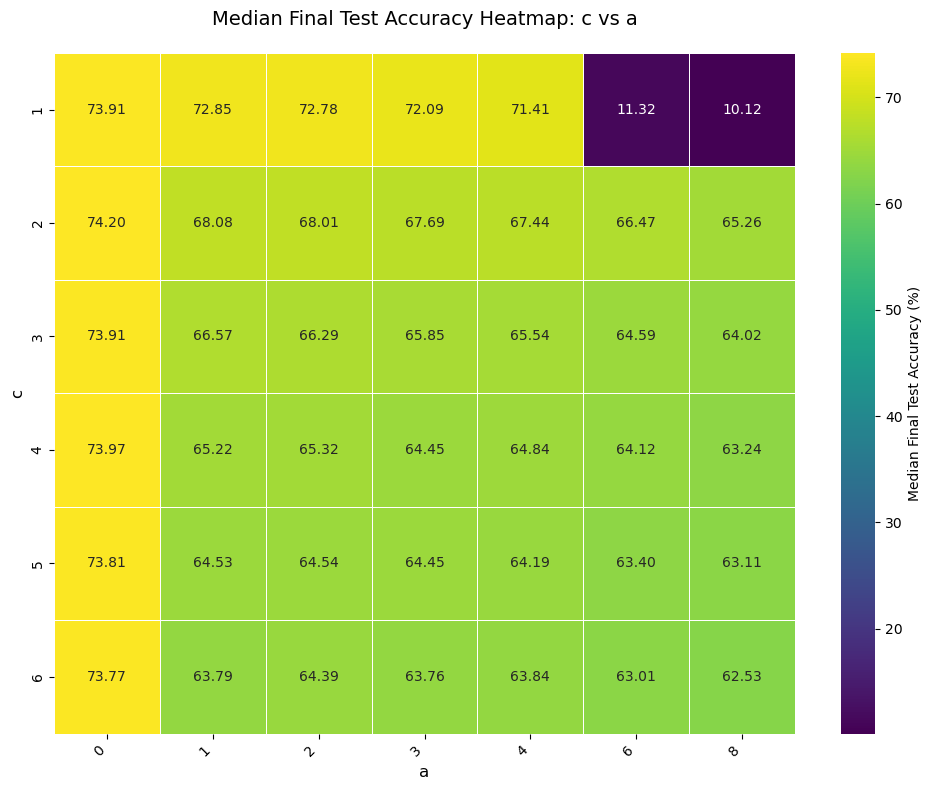

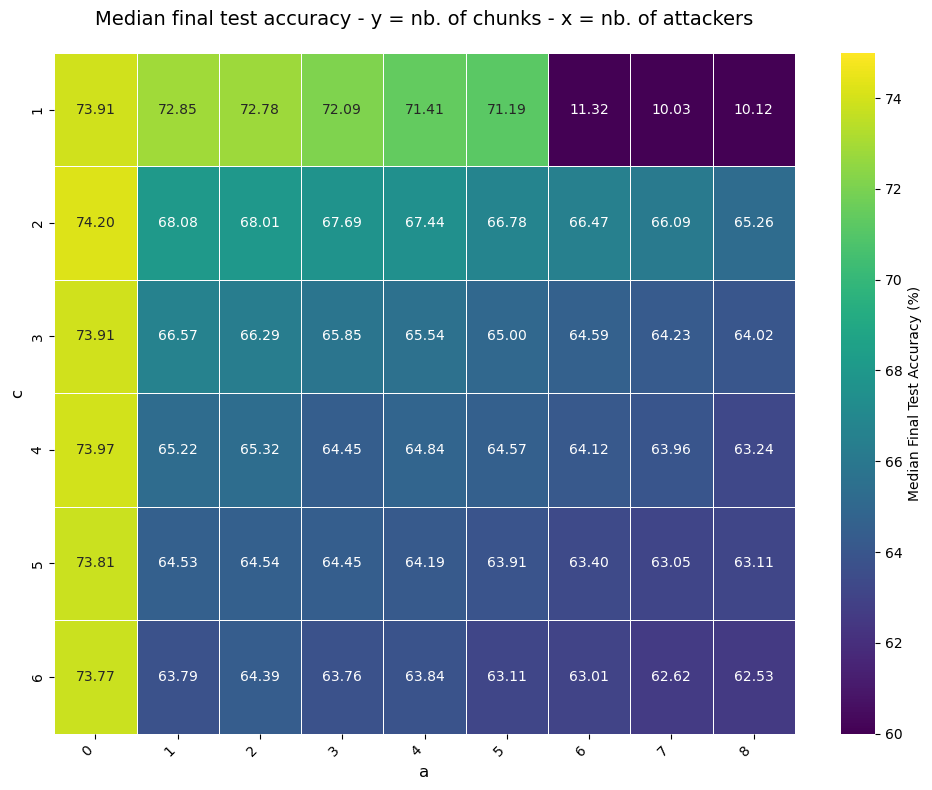

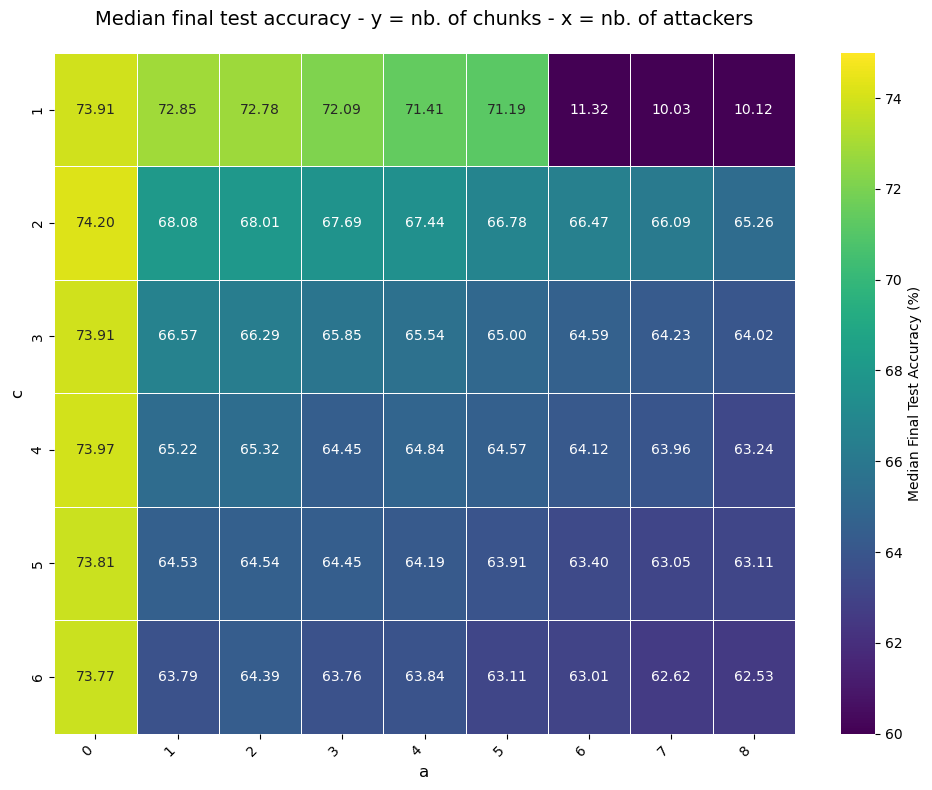

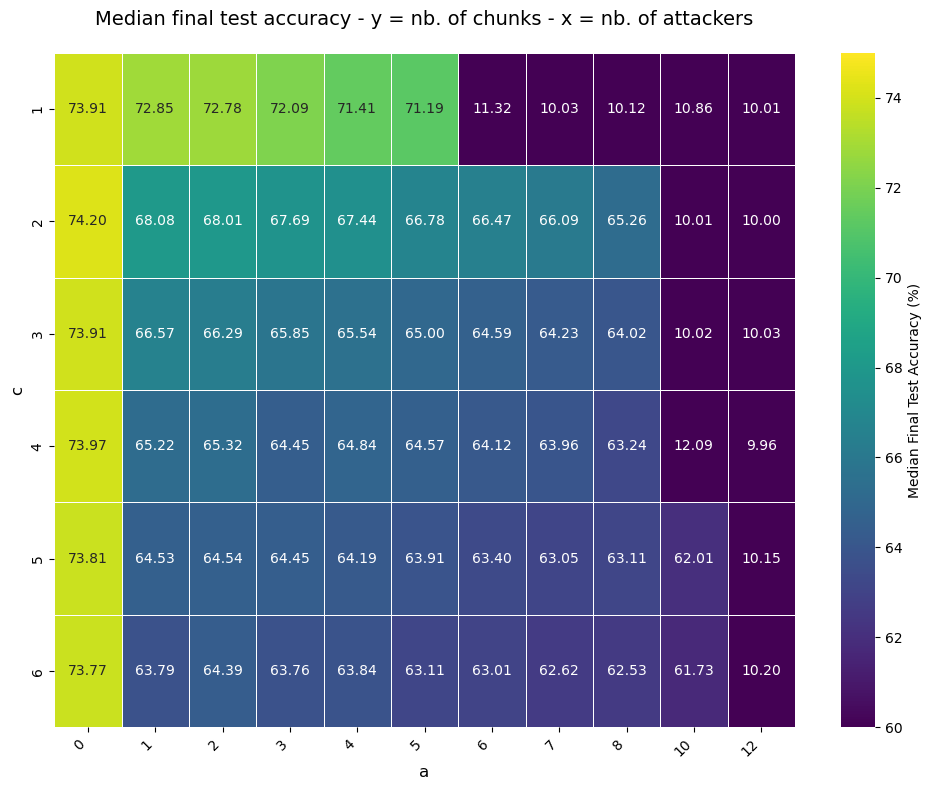

In [20]:
heatmap_selector = create_heatmap_selector()
display(heatmap_selector)

## 9. Save and Load Experiment Data

You can save your collected experiment data to a CSV file and load it back later:

In [11]:
def save_experiment_data(filepath, format="csv"):
    """
    Save the experiment data to a file
    
    Parameters:
    -----------
    filepath : str
        Path to save the file
    format : str
        File format: 'csv' for CSV format or 'pkl' for pickle format
        Pickle format preserves all data structures exactly as they are
    """
    df = collector.get_dataframe()
    if df.empty:
        print("No data to save.")
        return
    
    try:
        if format.lower() == "csv":
            # For CSV, we need to convert complex data to strings
            df_save = df.copy()
            # Convert adversarial_nodes to string representation for storage
            df_save['adversarial_nodes'] = df_save['adversarial_nodes'].apply(
                lambda x: ','.join(map(str, x)) if isinstance(x, list) else x
            )
            
            df_save.to_csv(filepath)
            print(f"Experiment data saved to {filepath} in CSV format")
            
        elif format.lower() == "pkl":
            import pickle
            # Save the entire collector object for complete state preservation
            with open(filepath, 'wb') as f:
                pickle.dump(collector, f)
            print(f"Experiment collector state saved to {filepath} in pickle format")
            
        else:
            print(f"Unsupported format: {format}. Use 'csv' or 'pkl'.")
            
    except Exception as e:
        print(f"Error saving data: {e}")

def load_experiment_data(filepath, format="csv"):
    """
    Load experiment data from a file
    
    Parameters:
    -----------
    filepath : str
        Path to the file to load
    format : str
        File format: 'csv' for CSV format or 'pkl' for pickle format
    """
    global collector  # We need to modify the global collector object
    
    try:
        if format.lower() == "csv":
            df = pd.read_csv(filepath)
            
            # Convert string representation of adversarial_nodes back to lists
            def parse_adv_nodes(value):
                # Handle integer values (stored directly)
                if isinstance(value, (int, float)) and not pd.isna(value):
                    return [int(value)]
                
                # Handle NaN values
                if pd.isna(value):
                    return None
                    
                # Handle string values (comma-separated list)
                if isinstance(value, str) and value.strip():
                    try:
                        return [int(node.strip()) for node in value.split(',')]
                    except ValueError:
                        print(f"Warning: Could not parse adversarial_nodes value: {value}")
                        return None
                
                # Return as is for other cases
                return value
                
            df['adversarial_nodes'] = df['adversarial_nodes'].apply(parse_adv_nodes)
            
            # Clear existing data
            collector.clear_data()
            
            # Add each row to the collector
            for _, row in df.iterrows():
                # Extract hyperparameters (columns that are not in the base columns)
                hyperparam_dict = {}
                for col in df.columns:
                    if col not in ['run_name', 'folder_path', 'median_final_acc', 'adversarial_nodes', 'Unnamed: 0']:
                        if not pd.isna(row[col]):
                            hyperparam_dict[col] = row[col]
                
                # Add the run directly to collector.data without recalculating metrics
                run_data = {
                    'run_name': row['run_name'],
                    'folder_path': row['folder_path'],
                    'median_final_acc': row['median_final_acc'],
                    'adversarial_nodes': row['adversarial_nodes']
                }
                
                # Add hyperparameters
                for param_name, param_value in hyperparam_dict.items():
                    run_data[param_name] = param_value
                    collector.hyperparam_names.add(param_name)
                    if param_name not in collector.columns:
                        collector.columns.append(param_name)
                
                collector.data.append(run_data)
                print(f"Added run '{row['run_name']}' with median final accuracy: {row['median_final_acc']:.2f}%")
                
            print(f"Loaded {len(df)} experiment runs from {filepath} (CSV format)")
            
        elif format.lower() == "pkl":
            import pickle
            # Load the entire collector object
            with open(filepath, 'rb') as f:
                loaded_collector = pickle.load(f)
            
            # Replace the current collector with the loaded one
            collector = loaded_collector
            print(f"Experiment collector state loaded from {filepath} (pickle format)")
            print(f"Loaded {len(collector.data)} experiment runs")
            
        else:
            print(f"Unsupported format: {format}. Use 'csv' or 'pkl'.")
            
    except Exception as e:
        print(f"Error loading data: {e}")

In [12]:
# Example usage - uncomment and modify as needed

# First clear any existing data
#clear_all_data()

# Load the experiment_data_1a.csv file
print("Loading experiment_data_1a.csv...")
load_experiment_data('experiment_data_1a.csv')

# View the loaded data
df_1a = view_collected_data()

Loading experiment_data_1a.csv...
Added run '3k_1c' with median final accuracy: 72.40%
Added run '3k_2c' with median final accuracy: 67.29%
Added run '3k_3c' with median final accuracy: 65.77%
Added run '3k_4c' with median final accuracy: 64.82%
Added run '4k_1c' with median final accuracy: 72.85%
Added run '4k_2c' with median final accuracy: 68.08%
Added run '4k_3c' with median final accuracy: 66.57%
Added run '4k_4c' with median final accuracy: 65.22%
Added run '5k_1c' with median final accuracy: 73.14%
Added run '5k_2c' with median final accuracy: 68.52%
Added run '5k_3c' with median final accuracy: 65.95%
Added run '5k_4c' with median final accuracy: 65.33%
Added run '8k_1c' with median final accuracy: 73.74%
Added run '8k_2c' with median final accuracy: 69.23%
Added run '8k_3c' with median final accuracy: 66.71%
Added run '8k_4c' with median final accuracy: 66.16%
Added run '12k_1c' with median final accuracy: 73.97%
Added run '12k_2c' with median final accuracy: 69.86%
Added run 

,run_name,folder_path,median_final_acc,adversarial_nodes,c,k
0,3k_1c,/home/pouponne/decentralized/shatter-poisoning...,72.40,[9],1,3
1,3k_2c,/home/pouponne/decentralized/shatter-poisoning...,67.29,[9],2,3
2,3k_3c,/home/pouponne/decentralized/shatter-poisoning...,65.77,[9],3,3
3,3k_4c,/home/pouponne/decentralized/shatter-poisoning...,64.82,[9],4,3
4,4k_1c,/home/pouponne/decentralized/shatter-poisoning...,72.85,[9],1,4
5,4k_2c,/home/pouponne/decentralized/shatter-poisoning...,68.08,[9],2,4
6,4k_3c,/home/pouponne/decentralized/shatter-poisoning...,66.57,[9],3,4
7,4k_4c,/home/pouponne/decentralized/shatter-poisoning...,65.22,[9],4,4
8,5k_1c,/home/pouponne/decentralized/shatter-poisoning...,73.14,[9],1,5
9,5k_2c,/home/pouponne/decentralized/shatter-poisoning...,68.52,[9],2,5


## Loading Different CSV Formats

The `load_experiment_data` function has been enhanced to handle different formats of the adversarial_nodes column:

1. Single integers (e.g., 9) - converts to a list with one element [9]
2. Comma-separated strings (e.g., "9,16,25") - converts to a list [9, 16, 25]
3. Empty or NaN values - converts to None

This makes the function more robust when dealing with CSV files saved in different formats or from different sources.

In [24]:
# Now try the experiment_data_4k.csv file for comparison
clear_all_data()

print("Loading experiment_data_4k.csv...")
load_experiment_data('experiment_data_4k.csv')

# View the loaded data
df_4k = view_collected_data()

All collected data has been cleared.
Loading experiment_data_4k.csv...
Added run '1c_0a' with median final accuracy: 73.91%
Added run '1c_1a' with median final accuracy: 72.85%
Added run '2c_0a' with median final accuracy: 74.20%
Added run '2c_1a' with median final accuracy: 68.08%
Added run '3c_0a' with median final accuracy: 73.91%
Added run '4c_0a' with median final accuracy: 73.97%
Added run '5c_0a' with median final accuracy: 73.81%
Added run '6c_0a' with median final accuracy: 73.77%
Added run '3c_1a' with median final accuracy: 66.57%
Added run '4c_1a' with median final accuracy: 65.22%
Added run '5c_1a' with median final accuracy: 64.53%
Added run '6c_1a' with median final accuracy: 63.79%
Added run '1c_2a' with median final accuracy: 72.78%
Added run '2c_2a' with median final accuracy: 68.01%
Added run '3c_2a' with median final accuracy: 66.29%
Added run '4c_2a' with median final accuracy: 65.32%
Added run '5c_2a' with median final accuracy: 64.54%
Added run '6c_2a' with media

,run_name,folder_path,median_final_acc,adversarial_nodes,a,c
0,1c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.915,None,0,1
1,1c_1a,/home/pouponne/decentralized/shatter-poisoning...,72.850,[9],1,1
2,2c_0a,/home/pouponne/decentralized/shatter-poisoning...,74.200,None,0,2
3,2c_1a,/home/pouponne/decentralized/shatter-poisoning...,68.080,[9],1,2
4,3c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.915,None,0,3
5,4c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.970,None,0,4
6,5c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.805,None,0,5
7,6c_0a,/home/pouponne/decentralized/shatter-poisoning...,73.770,None,0,6
8,3c_1a,/home/pouponne/decentralized/shatter-poisoning...,66.570,[9],1,3
9,4c_1a,/home/pouponne/decentralized/shatter-poisoning...,65.220,[9],1,4


## 10. Example Data (for Testing)

If you want to quickly test the functionality with some example data, you can run this cell to create some synthetic example runs:

In [ ]:
def add_example_data():
    """Add some example data for testing"""
    # Clear existing data
    collector.clear_data()
    
    # Define some hyperparameter values
    tau_values = [0.01, 0.05, 0.1, 0.5, 1.0]
    update_window_values = [1, 5, 10, 20]
    attack_type_values = ['zero', 'random', 'targeted']
    
    # Generate synthetic data
    np.random.seed(42)  # For reproducibility
    
    for i, tau in enumerate(tau_values):
        for j, window in enumerate(update_window_values):
            for k, attack in enumerate(attack_type_values):
                # Generate a synthetic accuracy value (higher is better)
                # This creates a pattern where medium tau values and higher window values generally perform better
                accuracy_base = 70.0  # Base accuracy value
                tau_factor = -25 * abs(tau - 0.1)  # Optimal at tau=0.1
                window_factor = 5 * (np.log(window))  # Higher window is better
                attack_factor = -5 if attack == 'targeted' else (-2 if attack == 'random' else 0)  # Zero attack is easiest
                
                # Add some randomness
                random_factor = np.random.normal(0, 3)
                
                # Calculate final synthetic accuracy
                accuracy = min(100, max(10, accuracy_base + tau_factor + window_factor + attack_factor + random_factor))
                
                # Create a dummy run entry
                run_name = f"{attack}_tau{tau}_win{window}"
                folder_path = f"/path/to/example/{run_name}"
                
                # Define adversarial nodes
                adv_nodes = [0, 1] if attack != 'zero' else [0]
                
                # Create a dictionary with hyperparameter values
                hyperparams = {
                    'tau_nbr': tau,
                    'update_window': window,
                    'attack_type': attack
                }
                
                # Manually create the run data and add it to collector
                run_data = {
                    'run_name': run_name,
                    'folder_path': folder_path,
                    'median_final_acc': accuracy,
                    'adversarial_nodes': adv_nodes,
                    **hyperparams
                }
                
                # Add to collector directly to avoid loading actual files
                collector.data.append(run_data)
                collector.hyperparam_names.update(hyperparams.keys())
    
    print(f"Added {len(collector.data)} example runs with synthetic data.")
    return collector.get_dataframe()

# Uncomment to add example data
# example_df = add_example_data()
# display(example_df)